Welcome to this notebook. In this notebook a simple neural network is demonstrated.<br>
Written by Bart Bozon, please copy & use as you would like.

1) The assignment: study the influence of the number of neurons in the hidden layers. Double them, quadruple them and assess the performance. Also study the size of the model and the time it needs to learn.
2) Bonus assignment: what is the result of a different activation function?

# Loading the data #

In [ ]:
import pandas as pd
url = 'https://raw.githubusercontent.com/bbozon/DataScience/refs/heads/main/Fish.csv'
#
# origin: https://documentation.sas.com/doc/en/statug/15.2/statug_sashelp_sect012.htm
# For each of the seven species (bream, roach, whitefish, parkki, perch, pike, and smelt),
# the weight, length, height, and width of each fish are tallied.
# Three different length measurements are recorded: from the nose of the fish to the beginning
# of its tail, from the nose to the notch of its tail, and from the nose to the end of its tail.
#
df = pd.read_csv(url)
df.head()

,Category,Species,Weight,Height,Width,Length1,Length2,Length3
0,1,Bream,242.0,11.5200,4.0200,23.2,25.4,30.0
1,1,Bream,290.0,12.4800,4.3056,24.0,26.3,31.2
2,1,Bream,340.0,12.3778,4.6961,23.9,26.5,31.1
3,1,Bream,363.0,12.7300,4.4555,26.3,29.0,33.5
4,1,Bream,430.0,12.4440,5.1340,26.5,29.0,34.0


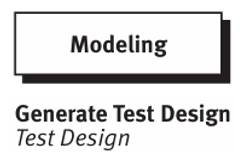

In [ ]:
X=df.drop(['Category','Species'],axis=1)
y=df['Species']

from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()                       # Use LabelEncoder to convert labels to integers
y_encoded = label_encoder.fit_transform(y)           # Automatically maps labels to integers

import numpy as np
max_classes=np.max(y_encoded)+1

import tensorflow as tf
y_one_hot = tf.keras.utils.to_categorical(y_encoded, num_classes=max_classes) # Convert integers to one-hot encoding
print (y_one_hot)

from sklearn.model_selection import train_test_split
# we always want to work with a training, validation and test data set
X_train, X_valid_plus_test, y_train, y_valid_plus_test = train_test_split(X, y_one_hot, test_size=0.2, random_state=42)
X_test, X_validation, y_test,y_validation = train_test_split(X_valid_plus_test, y_valid_plus_test, test_size=0.5, random_state=42)

[[1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 1. 0.]]


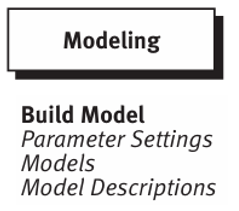

In [ ]:
model = tf.keras.models.Sequential([
   tf.keras.layers.Input(shape=(6,)),               # Input layer for 6 numerical features
    tf.keras.layers.Dense(16, activation='relu'),   # First hidden layer
    tf.keras.layers.Dense(16, activation='relu'),   # First hidden layer
    tf.keras.layers.Dense(max_classes, activation='softmax')  # Output layer for the amount of classes
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Summary of the model
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                      │ (None, 16)                  │             112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 16)                  │             272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 7)                   │             119 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 503 (1.96 KB)

 Trainable params: 503 (1.96 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(X_train, y_train, epochs=200, batch_size=32, validation_data=(X_validation, y_validation))

Epoch 1/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - accuracy: 0.0721 - loss: 91.6090 - val_accuracy: 0.0000e+00 - val_loss: 151.5072
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.0147 - loss: 94.4348 - val_accuracy: 0.0000e+00 - val_loss: 124.6808
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.0313 - loss: 74.4738 - val_accuracy: 0.0000e+00 - val_loss: 99.2846
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.0178 - loss: 62.2916 - val_accuracy: 0.0000e+00 - val_loss: 74.9908
Epoch 5/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.0031 - loss: 45.9224 - val_accuracy: 0.0000e+00 - val_loss: 52.7148
Epoch 6/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.0304 - loss: 38.2870 - val_accuracy: 0.1875 - val_loss: 35.9310
Epoch 7/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.2152 - loss: 28.6114 - val_accuracy: 0.3750 - val_loss: 33.6182
Epoch 8/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.2580 - loss: 23.93

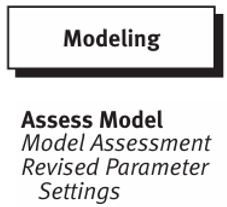

In [ ]:
val_loss, val_accuracy = model.evaluate(X_validation, y_validation)
print(f"Validation Loss: {val_loss}")
print(f"Validation Accuracy: {val_accuracy}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8125 - loss: 0.8032
Validation Loss: 0.8031702041625977
Validation Accuracy: 0.8125


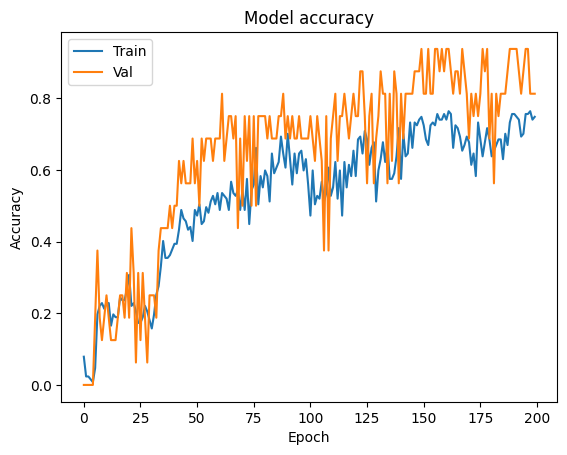

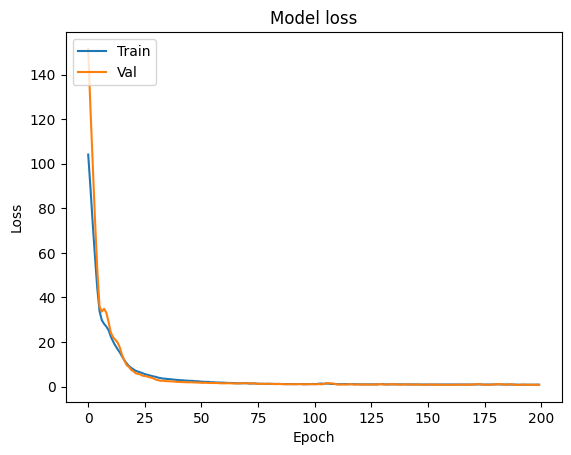

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
accuracy is : 0.75


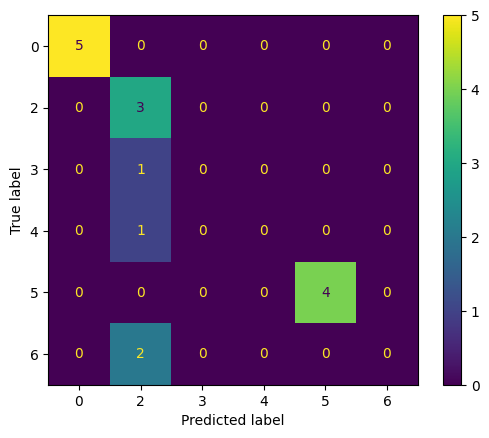

In [ ]:
# Make predictions on the test set
predictions = model.predict(X_test)
pred = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test, axis=1)
from sklearn.metrics import ConfusionMatrixDisplay,accuracy_score
import matplotlib.pyplot as plt
ConfusionMatrixDisplay.from_predictions(true_classes, pred)
print ('accuracy is :',accuracy_score(true_classes, pred))
